In [3]:
import sys
import os

# Change to project directory
os.chdir('/mnt/c/Users/NextGenn/Research/PP/gw-grb-joint-analysis')
sys.path.insert(0, os.getcwd())

# Test imports
import pandas as pd
from src import simulate_gw, simulate_grb, coincidence, statistics
from src.config import DELTA_T, DELTA_OMEGA

print("✓ All imports successful!")
print(f"Working directory: {os.getcwd()}")

✓ All imports successful!
Working directory: /mnt/c/Users/NextGenn/Research/PP/gw-grb-joint-analysis


In [4]:
# Step 1: Generate Simulated Data
gw_data = simulate_gw.simulate_gw_events(n=100)
grb_data = simulate_grb.simulate_grb_events(n=50)

print(f"✓ Generated {len(gw_data)} GW events")
print(f"✓ Generated {len(grb_data)} GRB events")
print("\nGW Data Sample:")
print(gw_data.head())

✓ Generated 100 GW events
✓ Generated 50 GRB events

GW Data Sample:
       time_gps        snr        ra       dec
0  1.126000e+09   9.216523  4.958510  1.078105
1  1.126000e+09  11.065787  5.852738  0.971758
2  1.126000e+09  10.585314  0.636925 -0.871156
3  1.126000e+09  14.036042  2.658132 -0.013486
4  1.126001e+09  12.528122  4.086385 -0.920312


In [5]:
# Step 2: Find Coincidences
coinc = coincidence.find_coincidences(gw_data, grb_data, DELTA_T, DELTA_OMEGA)
print(f"✓ Found {len(coinc)} coincidences!")
print("\nCoincidences:")
for i, c in enumerate(coinc[:5]):
    print(f"  {i+1}. GW time: {c[0]:.1f}, GRB time: {c[1]:.1f}, angle: {c[2]:.4f} rad")


✓ Found 0 coincidences!

Coincidences:


In [6]:
# Step 3: Compute Ranking Statistics
if len(coinc) > 0:
    ranking = statistics.ranking_statistic(1.0, 10.0)
    print(f"✓ Ranking statistic (example): {ranking:.4f}")
else:
    print("No coincidences to rank")

No coincidences to rank


In [7]:
# run in your notebook cell
from src.config import DELTA_T, DELTA_OMEGA
print("DELTA_T (s):", DELTA_T)
print("DELTA_OMEGA (rad):", DELTA_OMEGA)
print("GW time range:", gw_data.time_gps.min(), gw_data.time_gps.max())
print("GRB time range:", grb_data.time_gps.min(), grb_data.time_gps.max())

DELTA_T (s): 5.0
DELTA_OMEGA (rad): 0.2
GW time range: 1126000008.0228481 1126009819.9782047
GRB time range: 1126000064.876952 1126009855.0431323


In [8]:
import numpy as np

# time diffs (absolute) between all pairs
tdiff = np.abs(gw_data.time_gps.values[:,None] - grb_data.time_gps.values[None,:])
min_dt = tdiff.min()
print("Min time difference (s):", min_dt)

# angular separations (using coincidence.angular_distance if available)
from src.coincidence import angular_distance
ra_g, dec_g = gw_data.ra.values, gw_data.dec.values
ra_r, dec_r = grb_data.ra.values, grb_data.dec.values
# compute pairwise angles
ang = angular_distance(ra_g[:,None], dec_g[:,None], ra_r[None,:], dec_r[None,:])
min_ang = ang.min()
print("Min angular separation (rad):", min_ang, "≈", np.degrees(min_ang), "deg")

Min time difference (s): 1.3765928745269775
Min angular separation (rad): 0.005526512956524873 ≈ 0.31664586783324183 deg


In [9]:
# try larger search windows
coinc_wider = coincidence.find_coincidences(gw_data, grb_data, dt=30.0, domega=0.5)
len(coinc_wider), coinc_wider[:5]
# optionally write to CSV
import pandas as pd
pd.DataFrame(coinc_wider, columns=["gw_time","grb_time","angle_rad"]).to_csv("data/coincidences_debug.csv", index=False)


In [10]:
# find index of nearest pair
idx = np.unravel_index(np.argmin(tdiff + 1e6*ang), tdiff.shape)  # prioritize time then angle
i_g, i_r = idx
print("Nearest pair -> GW index:", i_g, "GRB index:", i_r)
print(gw_data.iloc[i_g].to_dict())
print(grb_data.iloc[i_r].to_dict())
print("time diff, angle (s, rad):", tdiff[i_g,i_r], ang[i_g,i_r])

Nearest pair -> GW index: 16 GRB index: 23
{'time_gps': 1126001538.9174967, 'snr': 7.626826243421786, 'ra': 4.945082501704028, 'dec': -1.4895390593237208}
{'time_gps': 1126004479.969589, 'fluence': 0.0017342159335011278, 'ra': 4.9236598748655895, 'dec': -1.4843117376700534}
time diff, angle (s, rad): 2941.0520923137665 0.005526512956524873


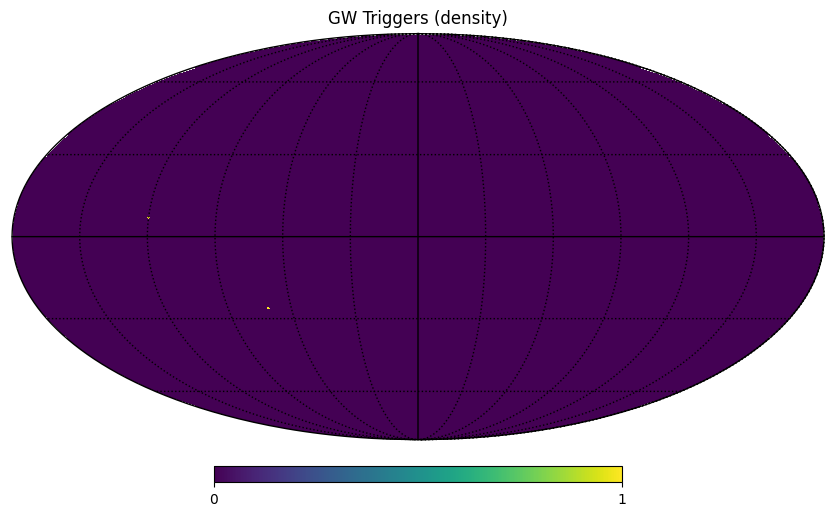

In [11]:
import numpy as np
import pandas as pd
import healpy as hp
import matplotlib.pyplot as plt

df = pd.read_csv("data/simulated/gw_triggers.csv")

ra = df["ra"].to_numpy()
dec = df["dec"].to_numpy()

# If values look like degrees (> 2π), convert to radians
if ra.max() > 2*np.pi:
    ra = np.deg2rad(ra)
    dec = np.deg2rad(dec)

theta = np.pi/2 - dec   # colatitude
phi = ra               # longitude (RA)

nside = 64
m = np.zeros(hp.nside2npix(nside))
pix = hp.ang2pix(nside, theta, phi)
for p in pix:
    m[p] += 1

hp.mollview(m, title="GW Triggers (density)")
hp.graticule()
plt.show()


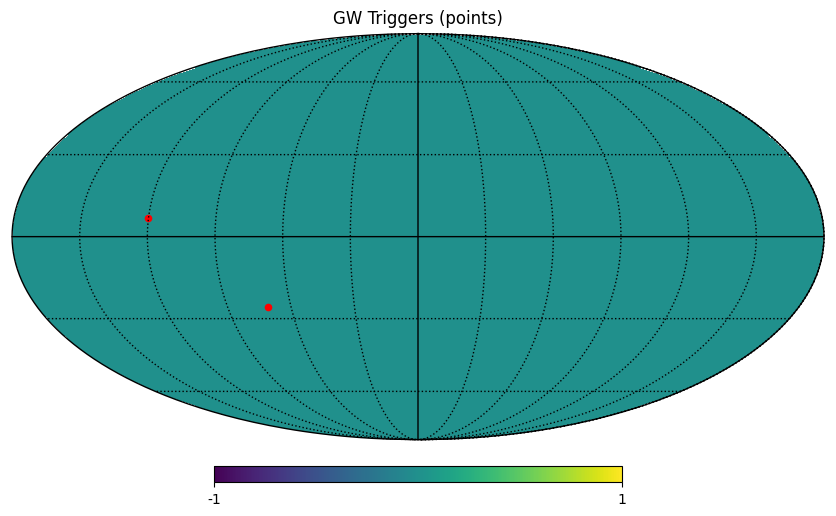

In [13]:
hp.mollview(np.zeros(hp.nside2npix(64)), title="GW Triggers (points)")
hp.projscatter(theta, phi, s=20, c="red")
hp.graticule()
plt.show()


In [16]:
plt.savefig("figures/gw_triggers_mollview.png", dpi=200, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

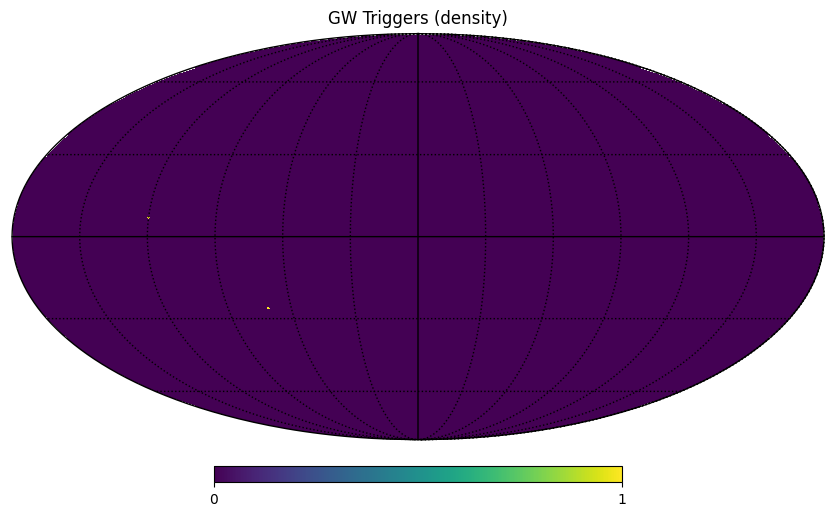

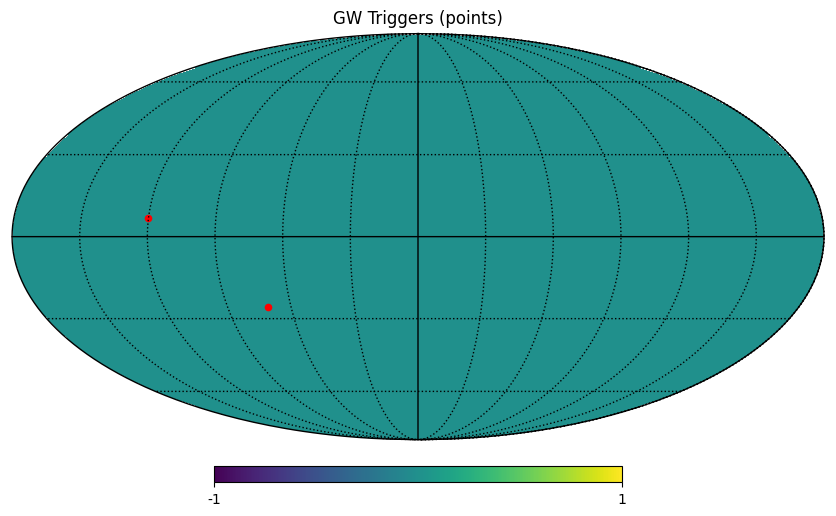

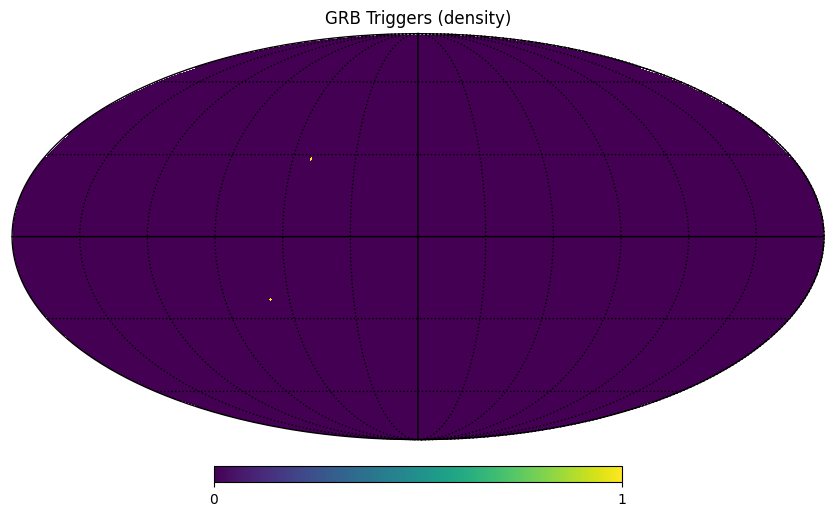

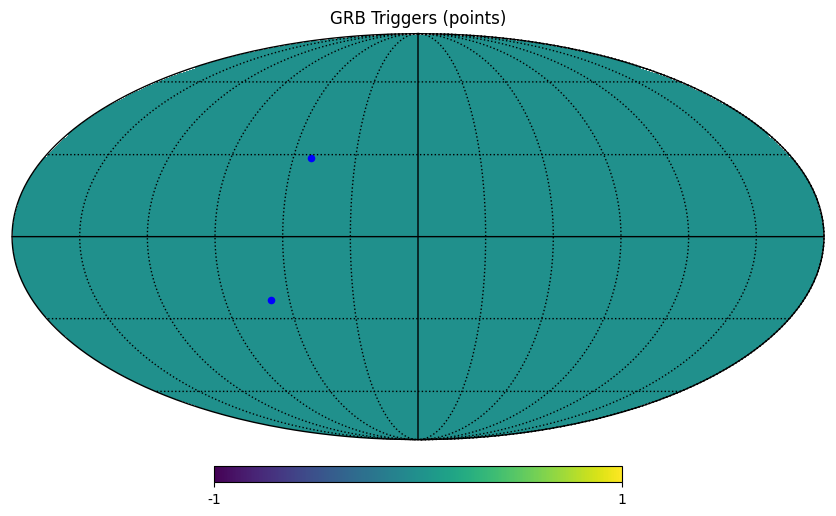

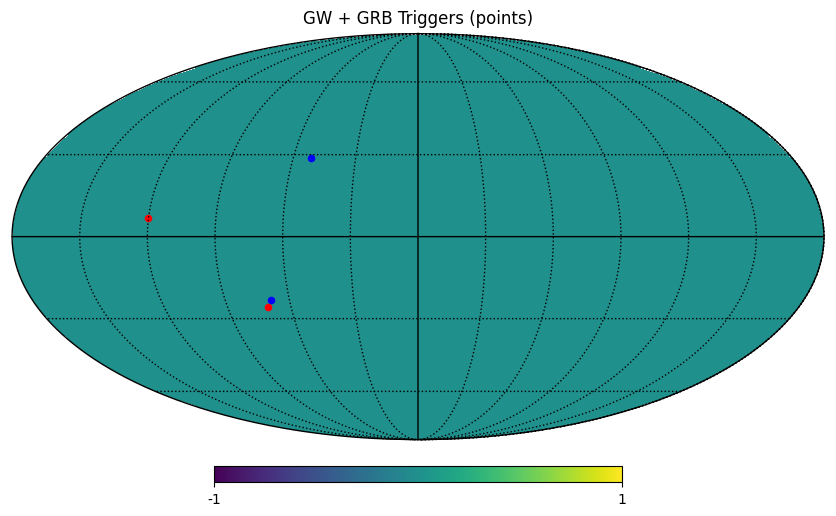

In [18]:
import numpy as np
import pandas as pd
import healpy as hp
import matplotlib.pyplot as plt
from pathlib import Path

def load_ra_dec(path):
    df = pd.read_csv(path)
    ra = df["ra"].to_numpy()
    dec = df["dec"].to_numpy()
    # Auto-detect degrees vs radians
    if ra.max() > 2*np.pi:
        ra = np.deg2rad(ra)
        dec = np.deg2rad(dec)
    theta = np.pi/2 - dec  # colatitude
    phi = ra               # longitude
    return theta, phi

def plot_density(theta, phi, title, outpath, nside=64):
    m = np.zeros(hp.nside2npix(nside))
    pix = hp.ang2pix(nside, theta, phi)
    for p in pix:
        m[p] += 1
    hp.mollview(m, title=title)
    hp.graticule()
    plt.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()

def plot_points(theta, phi, title, outpath, nside=64, color="red"):
    hp.mollview(np.zeros(hp.nside2npix(nside)), title=title)
    hp.projscatter(theta, phi, s=20, c=color)
    hp.graticule()
    plt.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()

# Load data
gw_theta, gw_phi = load_ra_dec("data/simulated/gw_triggers.csv")
grb_theta, grb_phi = load_ra_dec("data/simulated/grb_triggers.csv")

Path("figures").mkdir(exist_ok=True)

# 1. GW only (density + points)
plot_density(gw_theta, gw_phi, "GW Triggers (density)", "figures/gw_density.png")
plot_points(gw_theta, gw_phi, "GW Triggers (points)", "figures/gw_points.png", color="red")

# 2. GRB only (density + points)
plot_density(grb_theta, grb_phi, "GRB Triggers (density)", "figures/grb_density.png")
plot_points(grb_theta, grb_phi, "GRB Triggers (points)", "figures/grb_points.png", color="blue")

# 3. Combined (points)
hp.mollview(np.zeros(hp.nside2npix(64)), title="GW + GRB Triggers (points)")
hp.projscatter(gw_theta, gw_phi, s=20, c="red", label="GW")
hp.projscatter(grb_theta, grb_phi, s=20, c="blue", label="GRB")
hp.graticule()
plt.savefig("figures/gw_grb_combined_points.png", dpi=200, bbox_inches="tight")
plt.show()


In [19]:
import numpy as np
import pandas as pd
import healpy as hp
import matplotlib.pyplot as plt
from pathlib import Path

DEFAULT_NSIDE = 64
FIG_DIR = Path("figures")


def load_triggers(path):
    df = pd.read_csv(path)
    ra = df["ra"].to_numpy()
    dec = df["dec"].to_numpy()

    if np.nanmax(np.abs(ra)) > 2 * np.pi or np.nanmax(np.abs(dec)) > np.pi / 2:
        ra = np.deg2rad(ra)
        dec = np.deg2rad(dec)

    theta = np.pi / 2 - dec
    phi = ra
    return df, theta, phi


def density_map(theta, phi, nside=DEFAULT_NSIDE):
    m = np.zeros(hp.nside2npix(nside))
    pix = hp.ang2pix(nside, theta, phi)
    for p in pix:
        m[p] += 1
    return m


def save_mollview(m, title, outpath, unit="counts"):
    hp.mollview(m, title=title, unit=unit)
    hp.graticule()
    plt.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.close()


def save_colored_points(theta, phi, values, title, outpath, label, cmap="viridis"):
    hp.mollview(np.zeros(hp.nside2npix(DEFAULT_NSIDE)), title=title)
    sc = hp.projscatter(theta, phi, s=25, c=values, cmap=cmap)
    hp.graticule()
    cbar = plt.colorbar(sc, orientation="horizontal", pad=0.05)
    cbar.set_label(label)
    plt.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.close()


def save_publication_figure(gw_theta, gw_phi, grb_theta, grb_phi, gw_count, grb_count, outpath):
    fig = plt.figure(figsize=(8, 5))
    hp.mollview(
        np.zeros(hp.nside2npix(DEFAULT_NSIDE)),
        title="GW + GRB Trigger Sky Map",
        fig=fig.number
    )
    gw_sc = hp.projscatter(gw_theta, gw_phi, s=25, c="red", label="GW")
    grb_sc = hp.projscatter(grb_theta, grb_phi, s=25, c="blue", label="GRB")
    hp.graticule()

    ax = plt.gca()
    ax.legend(handles=[gw_sc, grb_sc], loc="lower left")
    ax.text(
        0.02, 0.02,
        f"GW: {gw_count}  GRB: {grb_count}",
        transform=ax.transAxes,
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
    )

    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.close(fig)


def main():
    FIG_DIR.mkdir(exist_ok=True)

    gw_df, gw_theta, gw_phi = load_triggers("data/simulated/gw_triggers.csv")
    grb_df, grb_theta, grb_phi = load_triggers("data/simulated/grb_triggers.csv")

    # 1) Combined density map (GW + GRB)
    m_total = density_map(gw_theta, gw_phi) + density_map(grb_theta, grb_phi)
    save_mollview(m_total, "GW + GRB Triggers (density)", FIG_DIR / "gw_grb_density.png")

    # 2) Points colored by SNR / fluence
    if "snr" in gw_df.columns:
        save_colored_points(
            gw_theta, gw_phi, gw_df["snr"].to_numpy(),
            "GW Triggers Colored by SNR",
            FIG_DIR / "gw_points_snr.png",
            label="SNR",
            cmap="magma"
        )

    if "fluence" in grb_df.columns:
        save_colored_points(
            grb_theta, grb_phi, grb_df["fluence"].to_numpy(),
            "GRB Triggers Colored by Fluence",
            FIG_DIR / "grb_points_fluence.png",
            label="Fluence",
            cmap="plasma"
        )

    # 3) Publication-style combined figure
    save_publication_figure(
        gw_theta, gw_phi, grb_theta, grb_phi,
        gw_count=len(gw_df), grb_count=len(grb_df),
        outpath=FIG_DIR / "gw_grb_publication.png"
    )

    print("Saved figures to:", FIG_DIR.resolve())


if __name__ == "__main__":
    main()


Saved figures to: /mnt/c/Users/NextGenn/Research/PP/gw-grb-joint-analysis/figures
